<h2>ANÁLISIS DISCRIMINANTE MÍNIMOS CUADRADOS PARCIALES (PLSDA)</h2>

<h4>Paquete ropls</h4>

In [18]:
load('.RData')

In [2]:
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(caret)
library(ropls)



Attaching package: ‘ropls’


The following object is masked from ‘package:tibble’:

    view




In [3]:
#Usamos el dataset sin datos NA
df <- na.omit(df_penguins)
df <- as.data.frame(df)
rownames(df) <- paste0(paste0(paste0(rownames(df), substr(df$species,1,1)), substr(df$island,1,1)), substr(df$sex,1,1))
head(df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
1ATm,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2ATf,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3ATf,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4ATf,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
5ATm,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
6ATf,Adelie,Torgersen,38.9,17.8,181,3625,female,2007


In [4]:
set.seed(72)
index <- createDataPartition(df$species, p = 0.75, list = FALSE)
train_data <- df[index, ]
test_data <- df[-index, ]
sprintf("The trainining set contains %d rows", nrow(train_data))
sprintf("The test set contains %d rows", nrow(test_data))

[1] "The trainining set contains 251 rows"

[1] "The test set contains 82 rows"

In [5]:
table(train_data$species)

train_balanced <- upSample(x = train_data, y = train_data$species)
train_balanced = train_balanced[, !(colnames(train_balanced) %in% c("Class"))]

table(train_balanced$species)


   Adelie Chinstrap    Gentoo 
      110        51        90 


   Adelie Chinstrap    Gentoo 
      110       110       110 

PLS-DA
330 samples x 4 variables and 1 response
standard scaling of predictors and response(s)
      R2X(cum) R2Y(cum) Q2(cum) RMSEE pre ort  pR2Y   pQ2
Total    0.864    0.759   0.757 0.232   2   0 0.001 0.001


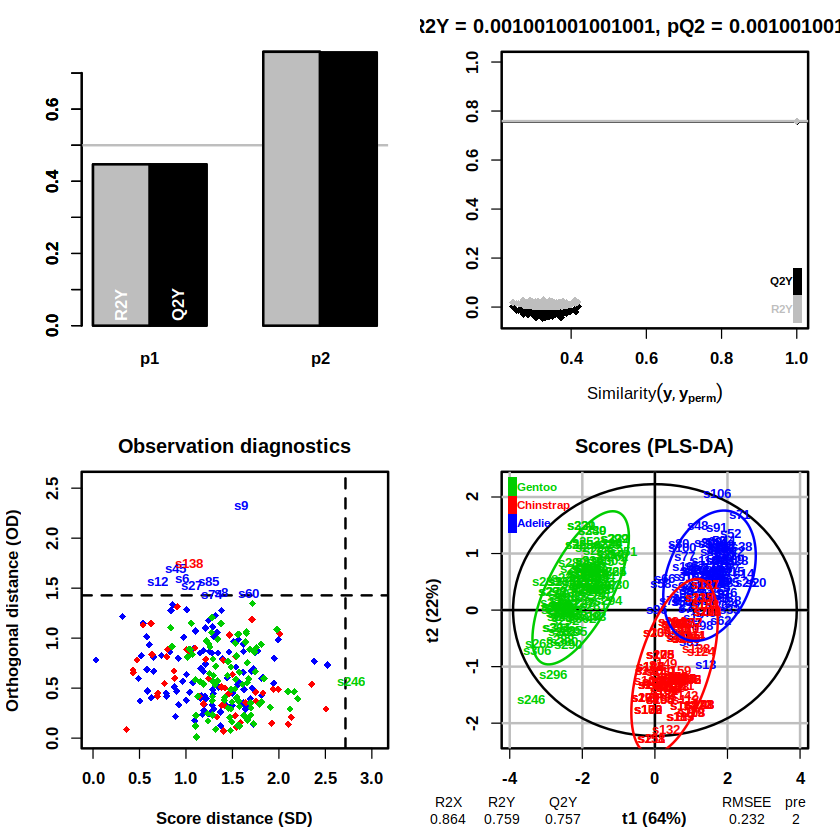

In [9]:
penguins.plsda <- opls(train_balanced[, 3:6], 
                       train_balanced$species,
                       predI = 2,
                       #permI = 999,
                       crossvalI = 10)

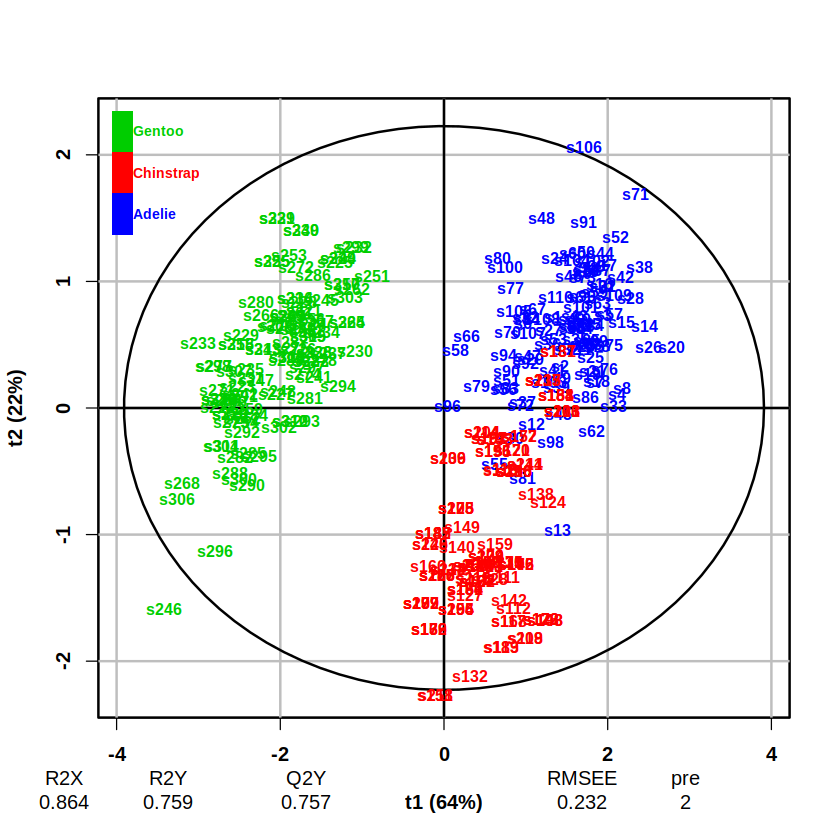

In [10]:
plot(penguins.plsda, typeVc = 'x-score',
     parEllipsesL = FALSE,
     parTitleL = FALSE
     #parCompVi = c(1, 3)
    )

In [11]:
plsda_preds <- predict(penguins.plsda, test_data[, 3:6])
confusionMatrix(data = plsda_preds, test_data$species)
paste('training error = ', round(mean(test_data$species != plsda_preds) * 100, 2), '%')


Confusion Matrix and Statistics

           Reference
Prediction  Adelie Chinstrap Gentoo
  Adelie        36         2      0
  Chinstrap      0        15      0
  Gentoo         0         0     29

Overall Statistics
                                         
               Accuracy : 0.9756         
                 95% CI : (0.9147, 0.997)
    No Information Rate : 0.439          
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.9615         
                                         
 Mcnemar's Test P-Value : NA             

Statistics by Class:

                     Class: Adelie Class: Chinstrap Class: Gentoo
Sensitivity                 1.0000           0.8824        1.0000
Specificity                 0.9565           1.0000        1.0000
Pos Pred Value              0.9474           1.0000        1.0000
Neg Pred Value              1.0000           0.9701        1.0000
Prevalence                  0.4390           0.2073

[1] "training error =  2.44 %"

<h4>Determinación sexo de los pinguinos con NA values</h4>

PLS-DA
333 samples x 4 variables and 1 response
standard scaling of predictors and response(s)
      R2X(cum) R2Y(cum) Q2(cum) RMSEE pre ort  pR2Y   pQ2
Total    0.866    0.569    0.56  0.33   2   0 0.001 0.001


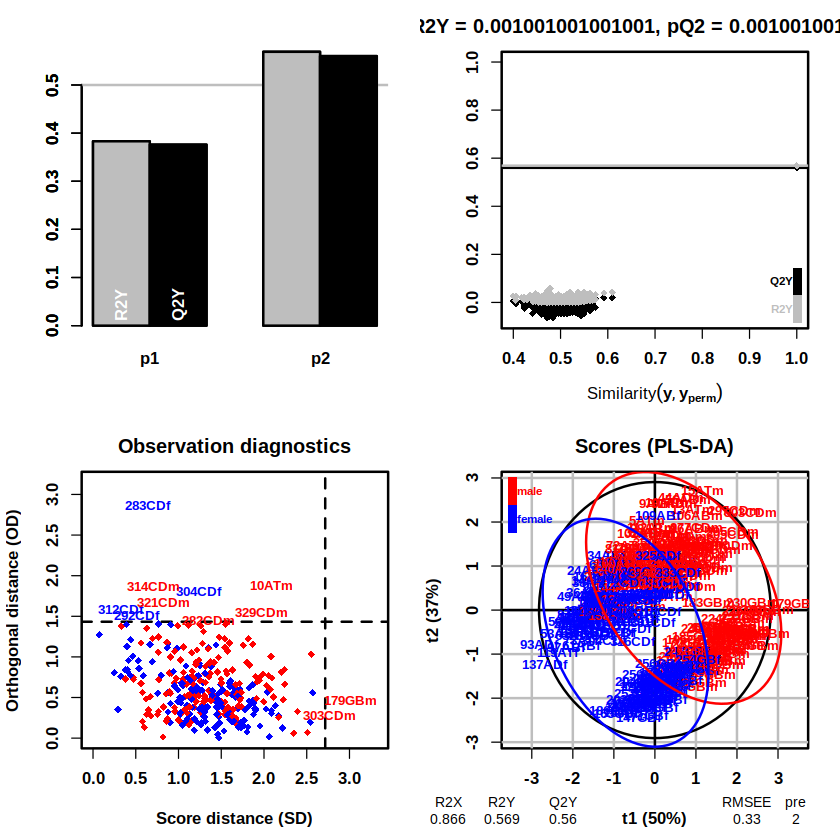

In [34]:
sex.plsda <- opls(df[, 3:6], 
                       df$sex,   
                       predI = 2, permI = 999,
                       crossvalI = 10)

In [36]:
sex_preds <- predict(sex.plsda, df[,3:6])
confusionMatrix(data = sex_preds, df$sex)
paste('training error = ', round(mean(df$sex != sex_preds) * 100, 2), '%')


Confusion Matrix and Statistics

          Reference
Prediction female male
    female    146   22
    male       19  146
                                          
               Accuracy : 0.8769          
                 95% CI : (0.8367, 0.9102)
    No Information Rate : 0.5045          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.7538          
                                          
 Mcnemar's Test P-Value : 0.7548          
                                          
            Sensitivity : 0.8848          
            Specificity : 0.8690          
         Pos Pred Value : 0.8690          
         Neg Pred Value : 0.8848          
             Prevalence : 0.4955          
         Detection Rate : 0.4384          
   Detection Prevalence : 0.5045          
      Balanced Accuracy : 0.8769          
                                          
       'Positive' Class : female          
                  

[1] "training error =  12.31 %"

In [38]:
df_NA <- df_penguins[!complete.cases(df_penguins), ]
df_NA <- data.frame(df_NA[c(2:10), ])
rownames(df_NA) <- paste0('NA', rownames(df_NA))
df_NA

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
NA1,Adelie,Torgersen,34.1,18.1,193,3475,NA,2007
NA2,Adelie,Torgersen,42.0,20.2,190,4250,NA,2007
NA3,Adelie,Torgersen,37.8,17.1,186,3300,NA,2007
NA4,Adelie,Torgersen,37.8,17.3,180,3700,NA,2007
NA5,Adelie,Dream,37.5,18.9,179,2975,NA,2007
NA6,Gentoo,Biscoe,44.5,14.3,216,4100,NA,2007
NA7,Gentoo,Biscoe,46.2,14.4,214,4650,NA,2008
NA8,Gentoo,Biscoe,47.3,13.8,216,4725,NA,2009
NA9,Gentoo,Biscoe,44.5,15.7,217,4875,NA,2009


In [41]:
NA_preds <- predict(sex.plsda, df_NA[,3:6])
df_NA$sex <- NA_preds
df_NA

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
NA1,Adelie,Torgersen,34.1,18.1,193,3475,female,2007
NA2,Adelie,Torgersen,42.0,20.2,190,4250,male,2007
NA3,Adelie,Torgersen,37.8,17.1,186,3300,female,2007
NA4,Adelie,Torgersen,37.8,17.3,180,3700,female,2007
NA5,Adelie,Dream,37.5,18.9,179,2975,female,2007
NA6,Gentoo,Biscoe,44.5,14.3,216,4100,female,2007
NA7,Gentoo,Biscoe,46.2,14.4,214,4650,female,2008
NA8,Gentoo,Biscoe,47.3,13.8,216,4725,female,2009
NA9,Gentoo,Biscoe,44.5,15.7,217,4875,female,2009


In [60]:
#str(penguins.plsda)
#coef(penguins.plsda)
getLoadingMN(penguins.plsda)
getSummaryDF(penguins.plsda)
getVipVn(penguins.plsda) # VIP: Variable importance in projection
getWeightMN(penguins.plsda)
show(penguins.plsda)

,p1,p2
bill_length_mm,-0.3873079,-0.86324970
bill_depth_mm,0.4235485,-0.59043644
flipper_length_mm,-0.6006673,-0.06306496
body_mass_g,-0.5688043,0.04737426


,R2X(cum),R2Y(cum),Q2(cum),RMSEE,pre,ort,pR2Y,pQ2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total,0.864,0.759,0.757,0.232,2,0,0.001001001,0.001001001


bill_length_mm     bill_depth_mm flipper_length_mm       body_mass_g 
        1.2787914         0.9157895         0.8867058         0.8601017

,p1,p2
bill_length_mm,-0.3430359,-0.90918193
bill_depth_mm,0.5209239,-0.34805284
flipper_length_mm,-0.5773336,0.01820911
body_mass_g,-0.5269255,0.22785053


PLS-DA
330 samples x 4 variables and 1 response
standard scaling of predictors and response(s)
      R2X(cum) R2Y(cum) Q2(cum) RMSEE pre ort  pR2Y   pQ2
Total    0.864    0.759   0.757 0.232   2   0 0.001 0.001


In [42]:
save.image()